Objective
- Personal counselor system built through analysis of my journals

<div>
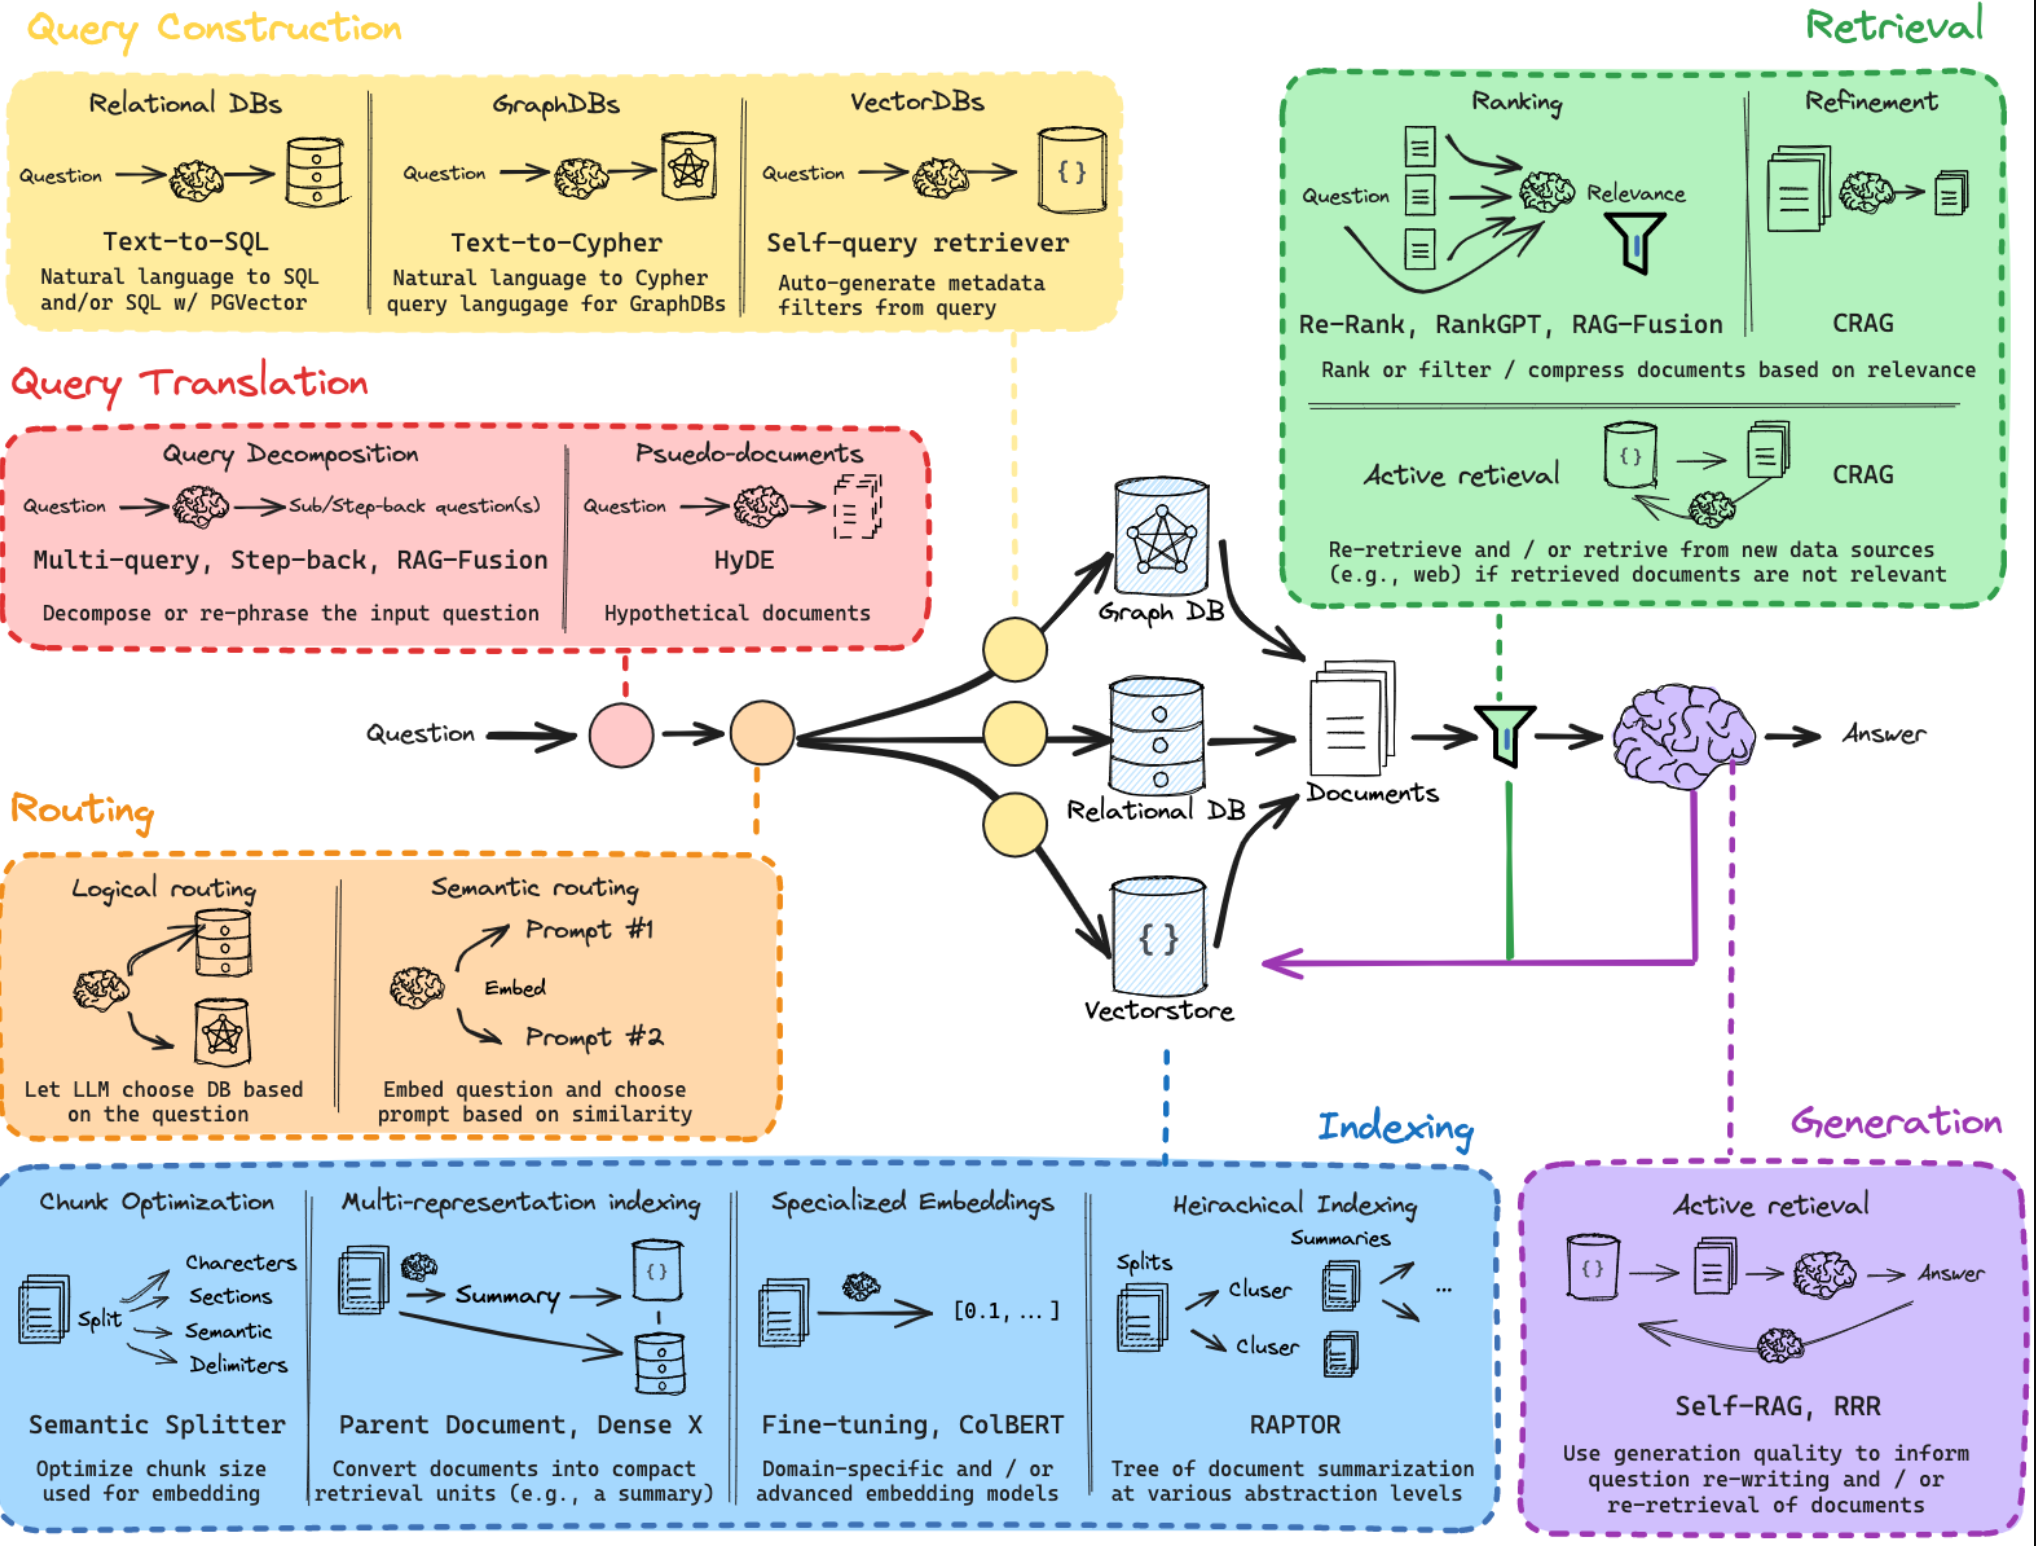
</div>

In [2]:
import numpy as np
import os
import pandas as pd
# import plotly as plt
import re, sys
# import tensorflow as tf
import torch
import torch.nn.functional as F

import langchain.text_splitter as lcts

In [1]:
!which python

/Users/haneulkim/miniforge3/envs/und_me/bin/python


In [3]:
print(sys.version)
print(sys.executable)
print(np.__version__)
print(pd.__version__)

3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:31:54) [Clang 16.0.6 ]
/Users/haneulkim/miniforge3/envs/und_me/bin/python
1.26.4
2.2.3


In [4]:
with open('diaries/20240912_20241030.txt', 'r') as f:
    journals = f.read()
with open('diaries/20241031_20241126.txt', 'r') as f:
    journals_2 = f.read()

In [5]:
journals = journals + '\n' + journals_2

1. Create a table consisting columns: date, content.

In [6]:
# str.splitlines(content)
date_lst = []
journal_lst = []

for j in journals.split("\n\n"):
    # This extracts (day n)
    date = re.findall(r'(\d{1,2}/\d{1,2}\s*(?:\([\w\s\d]*\))?)', j)[0]
    jnl = j.split(date)[-1]
    date_lst.append(re.findall(r'(\d{1,2}/\d{1,2})' , date)[0])
    journal_lst.append(jnl.replace("\n", ''))

In [7]:
journal_df = pd.DataFrame({"date":date_lst, "journal":journal_lst})

# 0. Data corrections

In [9]:
journal_df['date'] = pd.to_datetime('2024/'+journal_df['date'], format='%Y/%m/%d')

In [10]:
first_day = journal_df['date'].min()
last_day = journal_df['date'].max()
full_dates = pd.date_range(first_day, last_day, freq='D')
journal_df = (journal_df.set_index('date').reindex(full_dates)
               # .reset_index().rename(columns={"index":"date"})
             )

dayofweek_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday',
                4:'Friday', 5:'Saturday', 6:'Sunday'}
journal_df['dayofweek'] = journal_df.index.dayofweek.map(dayofweek_map)

## 0.1 Language correction

In [19]:
sentence_improve_prompt = """\
You are an English teacher, and your task is to provide feedback on every sentences I share. \
I aim to make my sentences more professional by improving their conciseness, structure, vocabulary, and grammar. \
The revised versions don’t need to follow the same format or wording as the originals, you can modify them freely \
to enhance clarity and effectiveness. Here are the steps you should follow:
1. Review the sentence.
2. Provide an improved version based on the specified criteria.
'{sentences}'"""

# 1. Chunking

In [23]:
journal_df['journal'] = f"Date is " + journal_df.index.astype(str) + ", " + journal_df['journal']
journals = "\n".join(journal_df.dropna(subset='journal')['journal'].tolist())
daily_chunks = journal_df['journal'].dropna().tolist()

## 1.1. Character chunking
- Chunks texts into N-characters.
- Chunks are stored in `document` object which holds metadata which makes filtering
  and manipulation easier.

In [25]:
chrc_text_splitter = lcts.CharacterTextSplitter(chunk_size = 35, chunk_overlap=10, separator=' ', strip_whitespace=False)
char_chunks = chrc_text_splitter.create_documents([journals])

## 1.2. Recursive character text splitting
- There are list of separaters. Starting from first separator to split texts however if splitted chunk is greater than chunk_size use next separator and so on...
- Default separators for LangChain = ['\n\n', '\n', ' ', '']

In [36]:
# pip install langchain_experimental fastembed langchain_community
from langchain_experimental.text_splitter import SemanticChunker
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.embeddings.fastembed import FastEmbedEmbeddings

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=0, # n of character overlap btwn chunks
    length_function=len, # length metric for chunks
    is_separator_regex=False
)

# # Below does not seem to work as expected
# text_punc_splitter = RecursiveCharacterTextSplitter(
#     chunk_size=300,
#     chunk_overlap=0, # n of character overlap btwn chunks
#     length_function=len, # length metric for chunks
#     is_separator_regex=False,
#     separators=['.', '?', '!'] #overrides default ['\n\n', '\n', ' ', ''] 
# )

recur_chunks = text_splitter.create_documents([journals])
recur_punc_chunks = text_splitter.create_documents(re.split(r'(?<=[.?!])\s+', journals))
# recursive_punc_chunks = text_punc_splitter.create_documents([journal_txt])

In [ ]:
# test
for a, b in zip(recur_punc_chunks, re.split(r'(?<=[.?!])\s+', journal_txt)):
    a = a.page_content
    if not a == b:
        print("uh oh... text_splitter.create_document function does extra chunking")
        break

## 1.3. Semantic Chunking
- Libraries: Langchain's `SemanticChunker` (Still in experimental), LlamaIndex's `SemanticSplitterNodeParser`

Basic mechanism is to chunk sentences when dissimilarity score exceeds threshold. dissimilarity score is simply distance between two chunk's embedding.
 -> This seems very compute intensive if we are trying with multiple split points.???

Steps:
1. Chunk sentences.
2. Compute similarity score between first and second sentence.
3. a) If below similarity threshold, set split point between them. <br>
   b) else, concat 1st and 2nd sentence. This becomes sentence_1 and third sentence becomes sentence_2
4. Repeat this process.

- `langchain_community`: library that allow langchain code to be easily integrated with third-party libraries.
- `fastembed`: Built by company named qdrant.
  - Light: FastEmbed is a lightweight library with few external dependencies. We don't require a GPU and don't download GBs of PyTorch dependencies, and instead use the ???ONNX Runtime. This makes it a great candidate for serverless runtimes like AWS Lambda.
  - Fast: FastEmbed is designed for speed. We use the ONNX Runtime, which is faster than PyTorch. We also use data parallelism for encoding large datasets.
  - Accurate: FastEmbed is better than OpenAI Ada-002. We also support an ever-expanding set of models, including a few multilingual models. 


In [37]:
emb_model_lc = FastEmbedEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model.onnx:   0%|          | 0.00/90.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

In [38]:
"""
Multiple different types of breakpoint_threshold_types
- standard_deviations
- interquartile
- gradient: useful when chunks are highly correlated or is specific to a domain.
"""
semantic_chunker = SemanticChunker(emb_model_lc, 
                                   breakpoint_threshold_type="percentile", # ???
                                   breakpoint_threshold_amount=0.8 # ??? what is default?
                                  )
smtc_recur_chunks = semantic_chunker.create_documents([d.page_content for d in recur_chunks])
smtc_recur_punc_chunks = semantic_chunker.create_documents([d.page_content for d in recur_punc_chunks])

In [68]:
journals_chunk_dict = {'char_chunks':char_chunks,
              'recur_chunks':recur_chunks, 'recur_punc_chunks':recur_punc_chunks,
              'smtc_recur_chunks':smtc_recur_chunks, 'smtc_recur_punc_chunks':smtc_recur_punc_chunks}

In [40]:
n_ex = 3
for c_name, c in journal_chunks.items():
    print(f"===== `{c_name}` has {len(c)} chunks, example of 3 chunks:")
    for i in range(n_ex):
        print(f"chunk {i}:", c[i].page_content)
        print()

===== `char_chunks` has 3575 chunks, example of 3 chunks:
chunk 0: Date is 2024-09-12, Today was the

chunk 1: was the first day of our mission.

chunk 2: mission. It’s hard to even call it

===== `recur_chunks` has 321 chunks, example of 3 chunks:
chunk 0: Date is 2024-09-12, Today was the first day of our mission. It’s hard to even call it a mission for me since I've been away from the church for so long. The ride from our hotel to the school where our mission is located was rough, but the view was spectacular. Surrounded by the world’s tallest

chunk 1: mountains, Nepal made me appreciate the majesty of these peaks. They looked sacred, and I could understand why Nepalese people revere each mountain, believing that some gods inhabit them. At first, I felt overwhelmed and somewhat useless (I suppose I feel that way too easily) when it seemed like

chunk 2: there wasn’t much I could do to help. It was my first time assisting dentists, and since I don’t regularly attend church, it felt 

# 2. Embedding

Contextual Retrieval [1]

Why? Usual bottleneck of RAG system is, retrieved chunk lacks contexts for example if I query "What was revenue growth for Hyundai" relevant chunk might contain text "Company's revenue grew by 10% over the previous quarter" which does not specify time or company.

- Uses two sub-techniques: Contextual embedding and contextual BM25.
- If knowledge base is smaller than 200,000 tokens (about 500 pages) giving entire knowledge base works well[1] ??? Should be checked


How? 
- Prepend chunk-specific explanatory context to each chunk before embedding.
- Previous tries: Hyde, summary-based indexing, etc... Antropic says this is different -> They just ask Claude to generate context for each chunk...


My opinion: Nothing special, marketing.

Ways to combine semantic embedding and BM25:
1. Create TF-IDF encodings and semantic embeddings for chunks.
2. Use BM25 to find top chunks based on exact matches.
3. Find top chunks based on semantic similarity.
4. Combine and deduplicate results from (2), (3) using rank fusion.

In [ ]:
## 2.2. Sentence transformers
# from sentence_transformers import SentenceTransformer
# model = SentenceTransformer('intfloat/multilingual-e5-large')
# embeddings = model.encode("Hello my name is Chris")
# print(embeddings)

=== Transformers ===

Below error when importing transformers but still seems to run...

"""<br>
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.<br>
"""

In [41]:
from transformers import AutoTokenizer, AutoModel

#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    # First element of model_output contains all token embeddings
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Works w/o downloading trained model into local machine.
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
emb_model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

2024-12-19 12:48:39.285372: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
tokens = tokenizer(journals, padding=True, 
                   truncation=True, return_tensors='pt')['input_ids']
tokens_2 = tokenizer([journals_2, journals_2][:10], padding=True, truncation=True, return_tensors='pt')
tokens_2['input_ids'].shape

In [42]:
def get_emb_tfsmrs(sentences, model):
    """
    Compute embedding of sentence using given emb_model.
    
    parameters
    ----------
    sentences: lst

    emb_model: transformer.models
    """
    encoded_input = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')
    
    with torch.no_grad():
        model_output = model(**encoded_input)
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
    return sentence_embeddings

In [ ]:
# embs_dict = {} # so this is like vectorDB...
# for chunk_nm, lst_of_docs in chunked_text_dict.items():
#     embs = get_emb_tfsmrs([c.page_content for c in chunked_text_dict[chunk_nm]], llm_emb_trsfmr)
#     embs_dict[chunk_nm] = embs

In [72]:
journal_chunks = [c.page_content for c in journals_chunk_dict['smtc_recur_punc_chunks']]
journal_embeddings = get_emb_tfsmrs(journal_chunks, emb_model)

In [49]:
journal_embeddings.shape

torch.Size([769, 384])

x = 42 <br>
y = x

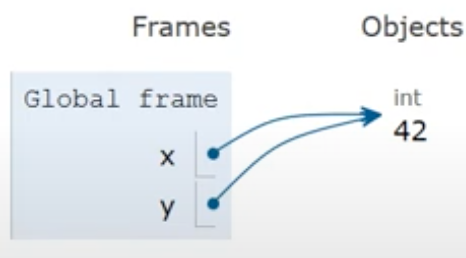

## 2.1. Store into Vector DB

# 3. Query transformation

HYDE
- HYpothetical Document Embedding retrieves (hypothetical) answer from LLM using your query and using that answer to retrieve nearest embeddings.

Multi-query expansion
- expand user's single query to multiple queries, retrieve embedding for each query then de-duplicate redundant ones using methods such as rank fusion.

ASTUTE RAG

Multi Hop

RAG-Fusion

In [ ]:
q1 = "When am I happy?"

# For q2 there is no real answer so seems like I cannot evaluate Retrieval
# or maybe give answer based on current thoughts?  -> So basically it is just simpler way to read journal...
q2 = "Now it is 2025 I want to travel again to a place where I can relax, learn history, and warm. Where should I go?" 

q3 = ""

## Query Templates

In [56]:
vanilla_template = '''
Answer the question based only on the following context:
{context}

Question: {query}
'''

In [57]:
journal_template = """
I have been writing journals in order to understand myself better. 
Answer the question with the help of following context, these are journals I've written myself:
{context}

Question: {query}
"""

## 3.1. Multi-Query

## 3.2. RAG-Fusion

## 3.3. HyDE

In [53]:
q1 = "What did I like most during my travels?"

In [54]:
q1_emb = get_emb_tfsmrs(q1, emb_model)

----

In [ ]:
test_sentences = ["This is about mathematics, dot product is used to compute distance and we consider magnitude and angle",
                 "My name is Haneul and I will be going to Delphi and Meteora today", 
                  "Mathematics is a large field where lot of specialized fields are within it such as calculus and linear algebra",
                 "Delphi is region where temple of apollo is located, it is where people in ancient greece came for prophecy",
                  "Statistics is also part of mathematics and also many sciences and it is why mathematics is considered queen of science",
                  "today we will go on 2 day tour where the price is 155 euros per person which is a good price for guided tour, bus, hotel, dinner and breakfast"
                 ]
sentence_embs = get_emb_tfsmrs(test_sentences, emb_model_lc)

q = ["What is mathematics"]
q_emb = get_emb_tfsmrs(q, emb_model_lc)

norm_a = np.linalg.norm(q_emb)
norm_b = np.linalg.norm(sentence_embs)
dot_product = np.dot(q_emb, sentence_embs.T)
cosine_sim = dot_product / (norm_a * norm_b)

topK = 2
print(f"Top {topK}")
print(np.array(test_sentences)[pd.Series(cosine_sim[0]).nlargest(topK).index])

print()
print()
print(f"Bottom {topK}")
print(np.array(test_sentences)[pd.Series(cosine_sim[0]).nsmallest(topK).index])

----

In [ ]:
# torch.is_tensor("d")

In [59]:
def compute_inner_product(m1, m2, ip_type="cosine"):    
    inner_product_matrix = np.dot(m1, m2.T)
    if ip_type == "cosine":
        norm_m1 = np.linalg.norm(m1)
        norm_m2 = np.linalg.norm(m2)
        inner_product_matrix = inner_product_matrix / (norm_m1 * norm_m2)
    else:
        raise Exception(f"not supported inner produce type: {ip_type}")
    return inner_product_matrix

In [77]:
def retrieve_context(q_emb, context_embs, context_lst, topK=3, ip_type='cosine'):
    """
    Retrive topK context that is most relevant to given query embedding(q_emb).
    
    parameters
    ----------
    q_emb: tensor object
    context_emb: tensor object
    context_lst: lst, list of strings. each elements is chunk of a journal.
    topK: int, number of context to retrieve
    ip_type: str, type of inner product to use when computing distance
    """
    ip_matrix = compute_inner_product(q_emb, context_embs, ip_type=ip_type)
    return np.array(context_lst)[pd.Series(ip_matrix[0]).nlargest(topK).index]

In [78]:
# ??? Instead of inputting context embeddings, it should be already stored in a database. Then q1_emb just searches it.
contexts = retrieve_context(q1_emb, journal_embeddings, journal_chunks, topK=5, ip_type='cosine')

In [81]:
print(vanilla_template.format(context=contexts, query=q1))


Answer the question based only on the following context:
['We’ve talked about our travels and this made me realize how much I was into travel destinations that are not easy, they are what I miss the most I think.'
 'They seemed to travelled to exotic places that had beautiful nature.'
 'But as I am watching the sunset thinking to myself that best travel for me is when I immerse myself into the culture.'
 'I will learn their history, language and culture and hold of this relaxing beach destinations for a while for next time I am employed but since I still have few days of these beach destination which I am very grateful of, I shall enjoy them to my fullest.'
 'He offered free breakfast at his hotel and well exceeding our expectations, hotel was pretty large scale and breakfast was best I’ve had during my travels.']

Question: What did I like most during my travels?



# 4. Retrieval

Context window:
- Gemini 1.5 flash [4]: Input token = 1,048,576, output token = 8,192

In [82]:
import os
import google.generativeai as genai

genai.configure(api_key=os.environ['GEMINI_API_KEY'])
gen_model = genai.GenerativeModel("gemini-1.5-flash")

In [83]:
context_retr_response = gen_model.generate_content(vanilla_template.format(
    context=contexts,
    query=q1))

In [84]:
full_context_response = gen_model.generate_content(vanilla_template.format(
    context=journals,
    query=q1))

In [85]:
print(context_retr_response.text)

Based on the provided text, you most enjoyed travel destinations that are not easy and involve immersion in the culture, learning the history and language.  You also appreciated a relaxing beach destination, and a hotel with excellent breakfast.



In [86]:
print(full_context_response.text)

Based on the provided text, there are several things the author enjoyed:

* **The majestic mountains of Nepal:** The author found the mountains sacred and appreciated the Nepalese people's reverence for them.
* **Learning new things:** The author found acquiring new knowledge, like scaling teeth, enjoyable.
* **The scenery during trekking in the Himalayas:** The author repeatedly mentions the beautiful scenery and unforgettable views, expressing gratitude for the mountains opening up to them.
* **Meeting new people:** The author enjoyed interacting with various people throughout their journey, learning from them, and forming connections, although they also experienced moments of loneliness and challenges in socializing.
* **Immersive cultural experiences:** The author appreciated truly immersing themselves in different cultures, like visiting a traditional Turkish hamam or experiencing a Greek hamam.  They found the relaxed atmosphere of Sicily and the vibrant street life of Palermo pa

In [87]:
%%time
q2 = "Family travel destinations?"
q2_emb = get_emb_tfsmrs(q2, emb_model)
contexts = retrieve_context(q2_emb, journal_embeddings, journal_chunks, topK=5, ip_type='cosine')
response = gen_model.generate_content(journal_template.format(context=contexts, query=q2))

CPU times: user 1.05 s, sys: 207 ms, total: 1.26 s
Wall time: 919 ms


In [88]:
print(response.text)

Based on your journal entries, there's no direct mention of family travel destinations.  Your entries focus on your personal preference for relaxing, exotic beach destinations that are best enjoyed when employed and needing a break.  The journals don't describe the presence or absence of family members during these trips.



- For q1, leveraging retrieved context(B) and journal entries(A) were equally good. 
- For q2, (A) did better. (B) failed to retrieve relevant context.

Takeaways:
1. Depending on what question is asked, performance differs between (A), (B) -> Is there a question where (A) works better?

# 5. Evaluation

Frameworks:
- Langchain Evals
- Llama Index Evals
- RAGAS Evals

RAGAS:
- evaluates both generation and retrieval parts.

Generation metrics:
- Faithfulness:
  - This is being calculated by LLM? -> Yes. -> ??? What is the prompt?
 
- Answer relevancy:
  - Check whether answers are relevant to initial question.
  - How? -> Use LLM to generate questions based on given answer then compare generated questions to original questions using cosine similarity.

Evaluation and Embedding models
- BaseRagasLLM and BaseRagasEmbeddings are the base classes Ragas used internally for LLMs and Embeddings. Any custom LLM or Embeddings should be a subclass of these base classes i.e. wrapped.

In [89]:
from datasets import load_dataset

In [90]:
dataset = load_dataset(
    "explodinggradients/amnesty_qa",
    "english_v3",
    trust_remote_code=True
)

Repo card metadata block was not found. Setting CardData to empty.


In [91]:
dataset["eval"].select(range(2))
print(dataset['eval'][0])

Dataset({
    features: ['user_input', 'reference', 'response', 'retrieved_contexts'],
    num_rows: 2
})

In [92]:
# load hf dataset into Ragas eval dataset
from ragas import EvaluationDataset
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, SemanticSimilarity
from ragas import evaluate

eval_dataset_sample = EvaluationDataset.from_hf_dataset(dataset["eval"].select(range(2)))
eval_dataset = EvaluationDataset.from_hf_dataset(dataset["eval"])

LLM-based metrics[5]
- LLMContextRecall, Faithfulness, FactualCorrectness, SemanticSimilarity(this uses emb_model)

-> Then basically all ragas is doing is filling up a prompt then sending it to LLM for scoring...???

In [98]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.testset import TestsetGenerator

evaluator_llm = LangchainLLMWrapper(gen_model)
evaluator_embs = LangchainEmbeddingsWrapper(emb_model) 

In [99]:
import google.auth

In [100]:
from langchain_google_vertexai import ChatVertexAI, VertexAIEmbeddings

In [ ]:
metrics = [
    LLMContextRecall(llm=evaluator_llm), 
    FactualCorrectness(llm=evaluator_llm), 
    Faithfulness(llm=evaluator_llm),
    SemanticSimilarity(embeddings=evaluator_embs)
]
results = evaluate(dataset=eval_dataset_sample, metrics=metrics)

Compatibility issue when using Gemini with HF. It seems to be missing certain
key that ragas is supposed to use.

In [ ]:
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o"))
evaluator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

In [ ]:
metrics = [
    LLMContextRecall(llm=evaluator_llm), 
    FactualCorrectness(llm=evaluator_llm), 
    Faithfulness(llm=evaluator_llm),
    SemanticSimilarity(embeddings=evaluator_embeddings)
]
results = evaluate(dataset=eval_dataset, metrics=metrics)

In [ ]:
results

In [ ]:
results.to_pandas()

Some thouhgs I've had.
As tools get developed
1. Competitions between tools.
2. Even little code for users. => Everyone can use it => less DS needed.
3. Leveraging tech for making value is important.

In [ ]:
df = results.to_pandas()

## Creating synthetic testset for RAG
<!-- !git clone https://huggingface.co/datasets/explodinggradients/Sample_Docs_Markdown -->


At the core there are 2 main operations that are performed to generate a testset.

KnowledgeGraph??? Creation: 
- Create a KnowledgeGraph using the documents you provide
- Use Transformations to enrich the knowledge graph with additional information that we can use to generate the testset. 


Testset Generation: 
- We use the KnowledgeGraph to generate a set of scenarios. These scenarios are used to generate the testset. You can learn more about this from the core concepts section.

In [ ]:
ls

In [ ]:
os.getcwd()

In [ ]:
from langchain_community.document_loaders import DirectoryLoader

# worked after `brew install libmagic
  # library that identify file type based on its content rather than file extension
path = "Sample_Docs_Markdown/"
loader = DirectoryLoader(path, glob="**/*.md")
docs = loader.load()

In [ ]:
# ??? So this, like previous ragas modules simply fills up a prompt for LLM to create
# synthethic dataset?

generator = TestsetGenerator(llm=evaluator_llm, embedding_model=evaluator_embeddings)
synthetic_dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

In [ ]:
docs[0].page_content

In [ ]:
docs[0].metadata

In [ ]:
synthetic_dataset.to_pandas()

Retrieval metrics
- Recall, Precision, MAP, MRR
- How to label retrieved chunks?
Ex: Precision = TP/(TP+FP)

Generation metrics
Factual correctness, Conciseness,

BLEU (BiLingual Evaluation Understudy):
  - Designed for machine translation
  - Measure text match between generated text and reference text

METEOR (Metric for Evaluation of Translation with Explicit ORdering):
  - Designed to address BLEU's limitation by considering recall, synonyms, and stemming.
  - So in BLEU if two sentence were semantically equivalent but had different sentence structure it would've had bad score. METEOR mitigate such problem but how???

ROUGE (Recall-Oriented Understudy for Gisting Evaluation):
  - Designed for summarization tasks
  - measures overlap between generated text and reference text.
    
  ROUGE Variants
  - ROUGE-N: Overlap of n-grams.
  - ROUGE-L: Longest Common Subsequence (LCS) for sentence structure.
  - ROUGE-S: Skip-bigram overlap, allowing non-contiguous matching.
    - Skip-bigram= 

BERTScore: Uses contextual embeddings from BERT to compare generated and reference texts semantically.

**NOTE: Reference texts are created only for few questions that will serve as gold standard.

In [ ]:
import evaluate # library from huggingface

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

In [ ]:
"""
The answer to such a question may vary over time. Unless I create a reference
text grounded in my journal, writing it based solely on my current emotions might 
not be entirely accurate. 
This could result in flawed performance metrics. 
For example, if context retrieval functions perfectly and retrieves all journal
entries related to my happiness, the generated sentence will accurately reflect 
my journal.
However, if the reference text addresses a slightly different topic, 
it could mislead the evaluation, favoring another generated answer that broadly 
discusses what makes people happy in general.
"""

q1= "During my travels, what events made me happy and sad?"
ref1 = "When I get my things done, be productive, help people out, see amazing scenary"

"""
Factural correctness measurement questions.
"""
q2="How long was I in Turkiye?"
ref2= "15 days"

q3="What are the foods that I've tried in Turkiye"
ref3="Kebab, Karniyarik, lokim, pottery kebab, etc..."

In [ ]:
%%time
q2 = "Family travel destinations?"
q2_emb = get_emb_tfsmrs(q2, llm_emb_trsfmr)
contexts = retrieve_context(q2_emb, journal_embeddings, 
                            journal_chunks, topK=5, ip_type='cosine')
response = model.generate_content(journal_template.format(context=journals, query=q2))

In [ ]:
q1_emb = get_emb_tfsmrs(q1, llm_emb_trsfmr)
q1_contexts = retrieve_context(q1_emb, journal_embeddings, 
                            journal_chunks, topK=5, ip_type='cosine')
gen1 = model.generate_content(journal_template.format(context=journals
                                , query=q1))
gen1_cr = model.generate_content(journal_template.format(context=q1_contexts
                                , query=q1))

In [ ]:
q2_emb = get_emb_tfsmrs(q2, llm_emb_trsfmr)
q2_contexts = retrieve_context(q2_emb, journal_embeddings, 
                            journal_chunks, topK=5, ip_type='cosine')
gen2 = model.generate_content(journal_template.format(context=journals
                                , query=q2))
gen2_cr = model.generate_content(journal_template.format(context=q2_contexts
                                , query=q2))

??? Must try to replicate BLEU score. From qualititative measure, gen1 >>> gen1_cr but reversed in BLEU

In [ ]:
bleu.compute(predictions=[gen1.text], references=[ref1], max_order=4)

In [ ]:
bleu.compute(predictions=[gen1_cr.text], references=[ref1])

In [ ]:
rouge.compute(predictions=[gen1.text], references=[ref1])

In [ ]:
rouge.compute(predictions=[gen1_cr.text], references=[ref1])

In [ ]:
print(q2)
print(ref2)

In [ ]:
print(gen2.text)

In [ ]:
print(q2_contexts)
print(gen2_cr.text)

$$
BLEU = BP* e^{\Sigma_{n=1}^{N}w_n logPn}
$$

- Pn: precision for n-grams
- w_n: weights for each n-gram precision. Default is uniform w_n = 1/N


???
$$
e^{\Sigma_{n=1}^{N}w_n logPn} = \Pi_{n=1}^{N}p_{n}^{w_n}
$$


BP = if c>r, then 1 <br>
    elif c≤r, then $e^{1−r/c}$

# 6. References
1. https://www.anthropic.com/news/contextual-retrieval
2. <a href='https://github.com/FullStackRetrieval-com/RetrievalTutorials/blob/main/tutorials/LevelsOfTextSplitting/5_Levels_Of_Text_Splitting.ipynb'>Chunking methods notebook</a>
3. LangHub: LangChain's home for prompt templates
4. <a href='https://ai.google.dev/gemini-api/docs/models/gemini?_gl=1*bdjshx*_up*MQ..&gclid=Cj0KCQiApNW6BhD5ARIsACmEbkUrqCO6XKLCuUz3X_m9keU80W75HI6dYaHEeZO2Hsb0WyTEX-5BW3gaArtuEALw_wcB#gemini-1.5-flash' >Google AI model specs</a>
5. <a href='https://docs.ragas.io/en/stable/getstarted/rag_evaluation/#working-with-data' >Getting started with ragas: evaluate using metrics</a>

# 99. Appendix

## Topic modeling

# Problem #1

Why does one context get retrieved always even if question changes?

## Deeplearing AI course on advanced RAG

Advanced retrieval techniques:
- Sentence window retrieval
- Automerging retrieval


`Sentence window retrieval` simply prepend and append previous and preceeding texts to retrieved text to give more context.

Evaluation metrics:
- Context relevance
- Groundedness
- Answer relevance



Context relevance


## Fine-tune/Evaluate/Quantize SLM/LLM using the torchtune on Azure ML

11/15 15:42~

- By centralizing settings into a YAML recipe, torchtune not only speeds up the experimentation process but also makes it easy to replicate or modify configurations across different models and tasks


Torchtune
- Simplifies fine-tuning, evaluation, and quantization of SLM/LLM using PyTorch.
- 